In [2]:
!pip install tensorflow
import sys
print(sys.version)
import tensorflow as tf
print(tf.__version__)


   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 744.6 kB/s eta 0:07:26
   ---------------------------------------- 0.5/332.0 MB 744.6 kB/s eta 0:07:26
   ---------------------------------------- 0.8/332.0 MB 788.5 kB/s eta 0:07:01
   ---------------------------------------- 1.0/332.0 MB 779.3 kB/s eta 0:07:05
   ---------------------------------------- 1.0/332.0 MB 779.3 kB/s eta 0:07:05
   ---------------------------------------- 1.3/332.0 MB 793.2 kB/s eta 0:06:57
   ---------------------------------------- 1.6/332.0 MB 806.8 kB/s eta 0:06:50
   ----------

In [1]:

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_size = (96, 96)

def robust_preprocess(img):
    # 1. Convert RGB → grayscale (shape information only)
    img = tf.image.rgb_to_grayscale(img)

    # 2. Mild contrast normalization (handles day/night/IR)
    img = tf.image.adjust_contrast(img, 1.3)

    # 3. Mild brightness variation (simulates lighting changes)
    img = tf.image.random_brightness(img, max_delta=0.15)

    # 4. Clip to valid range
    img = tf.clip_by_value(img, 0.0, 255.0)

    # 5. Duplicate channels for MobileNet
    img = tf.image.grayscale_to_rgb(img)

    return img



def full_preprocess(x):
    x = robust_preprocess(x)
    return preprocess_input(x)



train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    preprocessing_function=full_preprocess
)
train_generator = train_datagen.flow_from_directory(
    "dataset_binary",
    target_size=img_size,
    batch_size=16,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "dataset_binary",
    target_size=img_size,
    batch_size=16,
    class_mode="binary",
    subset="validation"
)


 

Found 16556 images belonging to 2 classes.
Found 4138 images belonging to 2 classes.


In [3]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Freeze initially
model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])


In [4]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="binary_crossentropy",
              metrics=["accuracy"])


In [6]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 368s 355ms/step - accuracy: 0.7406 - loss: 0.8257 - val_accuracy: 0.7731 - val_loss: 0.8406
Epoch 2/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 165s 159ms/step - accuracy: 0.7858 - loss: 0.6945 - val_accuracy: 0.7827 - val_loss: 0.7829
Epoch 3/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 163s 158ms/step - accuracy: 0.8038 - loss: 0.6417 - val_accuracy: 0.7883 - val_loss: 0.7606
Epoch 4/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 163s 157ms/step - accuracy: 0.8155 - loss: 0.6002 - val_accuracy: 0.7803 - val_loss: 0.7668
Epoch 5/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 166s 160ms/step - accuracy: 0.8255 - loss: 0.5750 - val_accuracy: 0.7924 - val_loss: 0.7318
Epoch 6/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 185s 179ms/step - accuracy: 0.8302 - loss: 0.5438 - val_accuracy: 0.7929 - val_loss: 0.7078
Epoch 7/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 224s 216ms/step - accuracy: 0.8373 - loss: 0.5299 - val_accuracy: 0.7968 - val_loss: 0.6931
Epoch 8/20
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 198s 192ms/step - ac

In [7]:
test_datagen = ImageDataGenerator(preprocessing_function=full_preprocess)
test_generator = test_datagen.flow_from_directory(
    "dataset/test",   # Put your 300 test images here
    target_size=img_size,
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)


Found 190 images belonging to 2 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.8000 - loss: 0.4835
Test Accuracy: 0.800000011920929


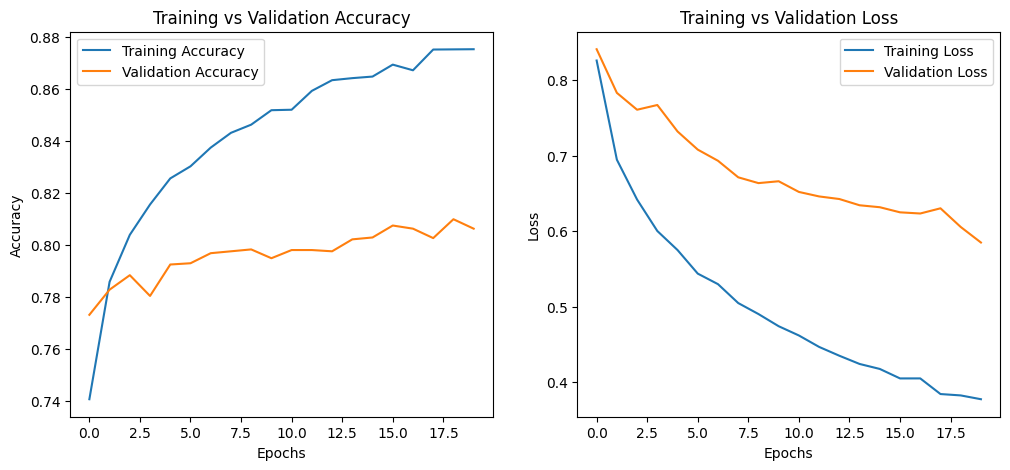

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [12]:
from tensorflow.keras.preprocessing import image

img = image.load_img("jungle.jpg", target_size=(96, 96))

img_array = image.img_to_array(img)
img_array = preprocess_input(img_array)   # <-- IMPORTANT

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

if prediction < 0.5:
    print("Elephant detected!")
else:
    print("Not an elephant.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Not an elephant.


In [13]:
model.save("elephant_model.keras")


In [14]:
#fine tuning generators

fine_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    preprocessing_function=full_preprocess
)

train_ft = fine_datagen.flow_from_directory(
    "finetune_dataset",
    target_size=img_size,
    batch_size=8,
    class_mode="binary",
    subset="training"
)

val_ft = fine_datagen.flow_from_directory(
    "finetune_dataset",
    target_size=img_size,
    batch_size=8,
    class_mode="binary",
    subset="validation"
)

Found 62 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


In [15]:
model = tf.keras.models.load_model("elephant_model.keras")

In [16]:
base_model = model.layers[0]   # MobileNetV2 backbone

for layer in base_model.layers[-20:]:
    layer.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


In [17]:


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [18]:
history_ft = model.fit(
    train_ft,
    validation_data=val_ft,
    epochs=8
)


Epoch 1/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - accuracy: 0.4032 - loss: 1.1582 - val_accuracy: 0.3571 - val_loss: 1.4787
Epoch 2/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5161 - loss: 1.1086 - val_accuracy: 0.5714 - val_loss: 1.0835
Epoch 3/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5323 - loss: 1.0491 - val_accuracy: 0.3571 - val_loss: 1.4363
Epoch 4/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5161 - loss: 1.0741 - val_accuracy: 0.3571 - val_loss: 1.1325
Epoch 5/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5806 - loss: 0.9239 - val_accuracy: 0.5000 - val_loss: 1.0834
Epoch 6/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.6129 - loss: 0.9456 - val_accuracy: 0.5000 - val_loss: 1.0388
Epoch 7/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6129 - loss: 0.9364 - val_accuracy: 0.6429 - val_loss: 1.1417
Epoch 8/8
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6129 - loss: 0.8047 - val_accuracy: 0.5714 - val_loss: 0.8730


In [19]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.7421 - loss: 0.6355
Test Accuracy: 0.74210524559021


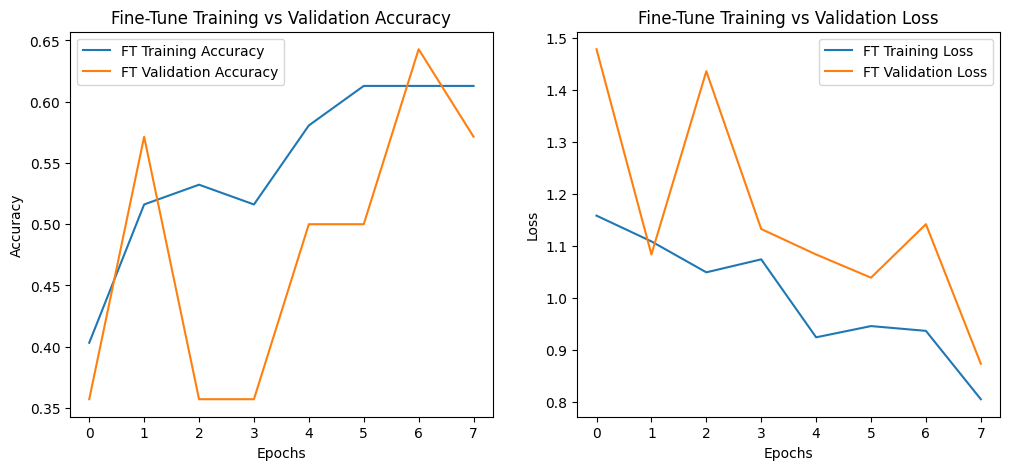

In [20]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_ft.history["accuracy"], label="FT Training Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="FT Validation Accuracy")
plt.title("Fine-Tune Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_ft.history["loss"], label="FT Training Loss")
plt.plot(history_ft.history["val_loss"], label="FT Validation Loss")
plt.title("Fine-Tune Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


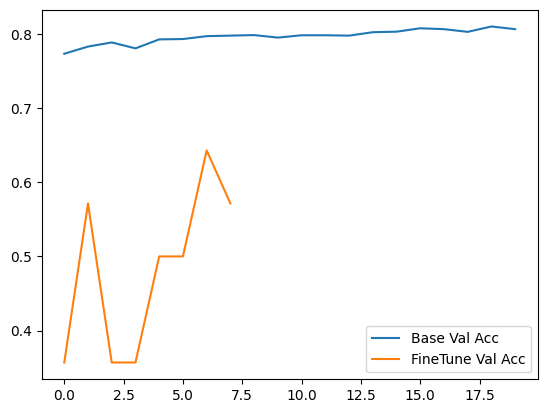

In [21]:
plt.plot(history.history["val_accuracy"], label="Base Val Acc")
plt.plot(history_ft.history["val_accuracy"], label="FineTune Val Acc")
plt.legend()

In [22]:
model.save("elephant_model_finetuned.keras")

In [23]:
import os 
size_keras = os.path.getsize("elephant_model_finetuned.keras")/(1024*1024)
print(f"model size is {size_keras}")

model size is 20.311923027038574


In [25]:


# ----------------------------
# Load your FINE-TUNED model
# ----------------------------
model = tf.keras.models.load_model("elephant_model_finetuned.keras", compile=False)

IMG_SIZE = (96, 96)

# ----------------------------
# Representative dataset
# MUST match training preprocess
# ----------------------------
def representative_data_gen():

    calib_dir = "calibration_data"

    for root, _, files in os.walk(calib_dir):
        for fname in files:

            if not fname.lower().endswith((".jpg",".jpeg",".png")):
                continue

            path = os.path.join(root, fname)

            img = image.load_img(path, target_size=IMG_SIZE)
            img = image.img_to_array(img)

            # SAME preprocessing as training
            img = preprocess_input(img)

            img = np.expand_dims(img, axis=0).astype(np.float32)

            yield [img]

# ----------------------------
# Converter
# ----------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# INT8 internal ops but float input/output
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

# keep float IO — avoids mismatch
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open("elephant_int8.tflite","wb") as f:
    f.write(tflite_model)

print("Quantized model saved.")


INFO:tensorflow:Assets written to: C:\Users\KSDESHAN\AppData\Local\Temp\tmpzi1m6e_p\assets


INFO:tensorflow:Assets written to: C:\Users\KSDESHAN\AppData\Local\Temp\tmpzi1m6e_p\assets


Saved artifact at 'C:\Users\KSDESHAN\AppData\Local\Temp\tmpzi1m6e_p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3086200765904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200764944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200765136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200764560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200764752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200765712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200763408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200763600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200763216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3086200764176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  308

C:\Users\KSDESHAN\anaconda3\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized model saved.
